In [1]:
# Install required packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
import os

import os

def load_dataset():
    """
    Loads city_day.csv either from Kaggle (via kagglehub) or via manual upload.
    Returns a pandas DataFrame.
    """
    try:
        import kagglehub
        path = kagglehub.dataset_download('rohanrao/air-quality-data-in-india')
        csv_path = os.path.join(path, 'city_day.csv')
        df = pd.read_csv(csv_path)
        print(f'Dataset loaded automatically from Kaggle: {csv_path}')
        return df
    except Exception as e:
        print(f'Automatic Kaggle download failed: {e}')
        print('Please upload city_day.csv manually (download it from Kaggle first).')
        try:
            from google.colab import files=-
            uploaded = files.upload()
            filename = list(uploaded.keys())[0]
            df = pd.read_csv(filename)
            print(f'Dataset loaded from manual upload: {filename}')
            return df
        except Exception as e2:
            raise FileNotFoundError(f'Could not load dataset by any method: {e2}')

df = load_dataset()
df.head()

SyntaxError: invalid syntax (3727736387.py, line 21)

In [ ]:
print('Dataset Shape:', df.shape)
print()
print('Column Info:')
df.info()
print()
print('Statistical Summary:')
df.describe()

Dataset Shape: (29531, 16)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB

Statistical Summary:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [ ]:
try:
    print('Missing values BEFORE cleaning:')
    print(df.isnull().sum())

    # Convert Date column
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Ensure pollutant/AQI columns are numeric
    pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
    for col in pollutant_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows with missing target (AQI)
    df_clean = df.dropna(subset=['AQI']).copy()

    # Fill missing pollutant values with median
    feature_cols_all = pollutant_cols[:-1]
    for col in feature_cols_all:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Remove duplicates
    before = df_clean.shape[0]
    df_clean = df_clean.drop_duplicates()
    after = df_clean.shape[0]
    print(f'\nRemoved {before - after} duplicate rows')

    # Final safety drop (in case any column still has NaNs)
    df_clean = df_clean.dropna(subset=feature_cols_all)

    print('\nMissing values AFTER cleaning:', df_clean.isnull().sum().sum())
    print('Final cleaned dataset shape:', df_clean.shape)
except Exception as e:
    print(f' Error during preprocessing: {e}')

Missing values BEFORE cleaning:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Removed 0 duplicate rows

Missing values AFTER cleaning: 24733
Final cleaned dataset shape: (24850, 16)


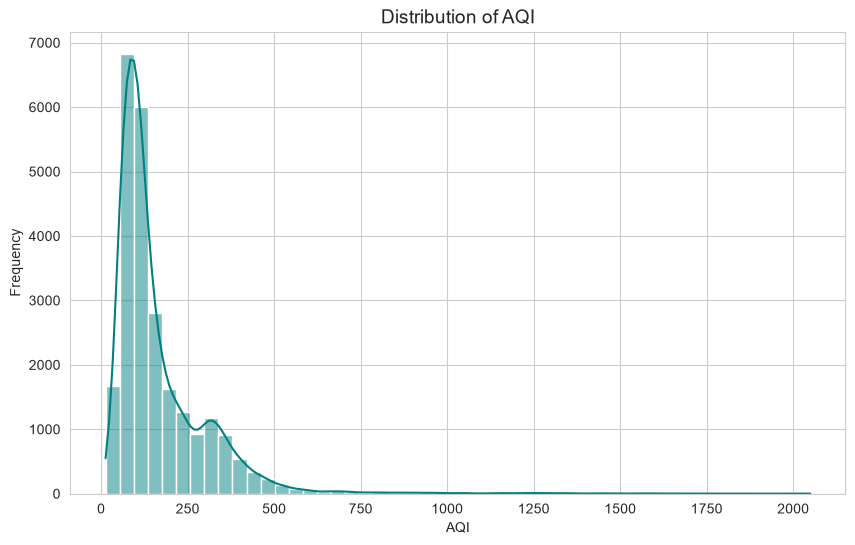

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['AQI'], bins=50, kde=True, color='teal')
plt.title('Distribution of AQI', fontsize=14)
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

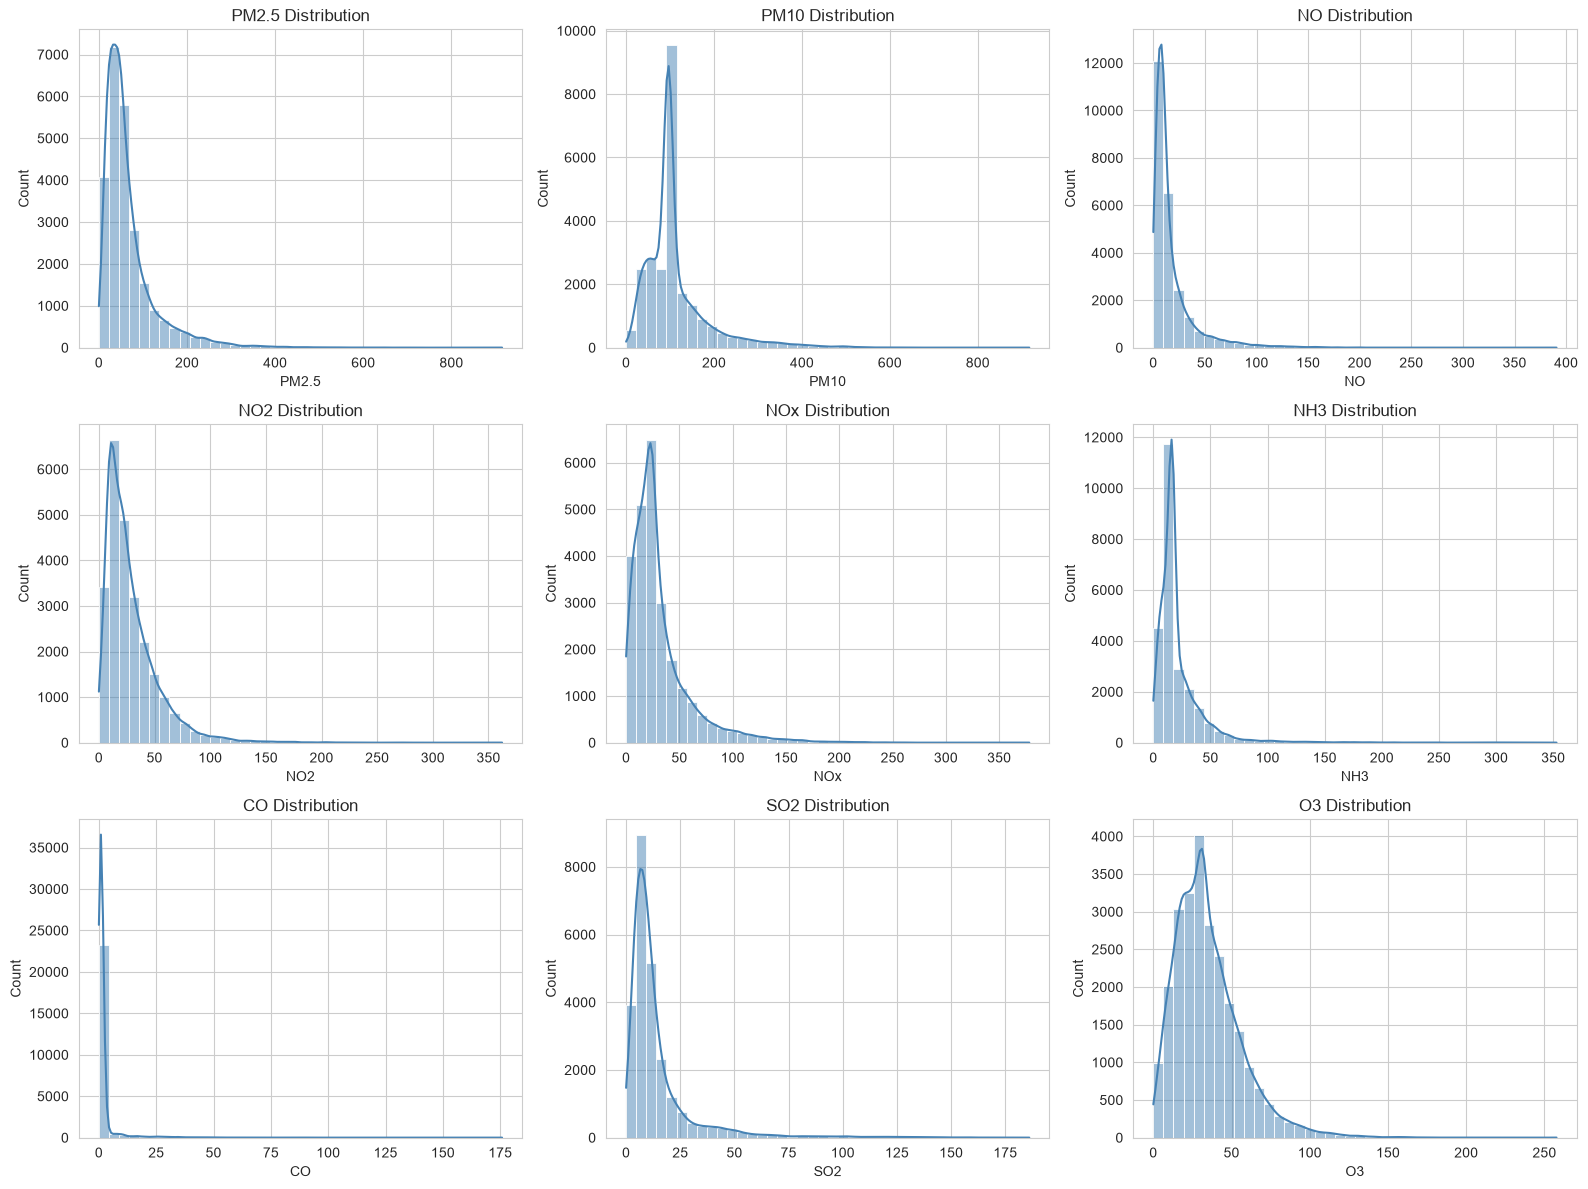

In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(pollutants):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

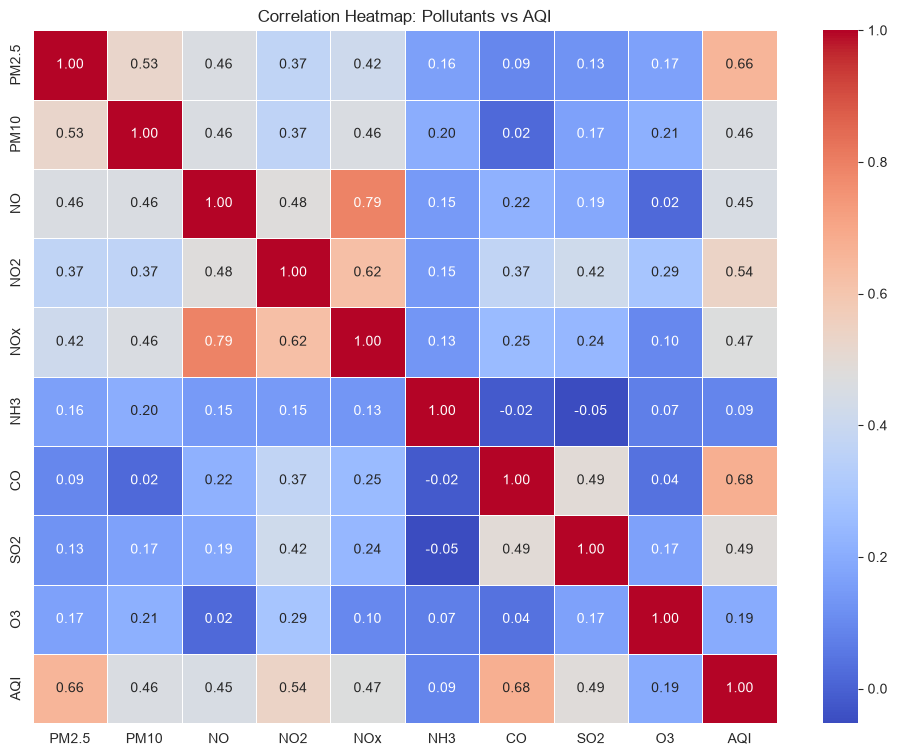

In [ ]:
plt.figure(figsize=(12, 9))
corr = df_clean[pollutants + ['AQI']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Pollutants vs AQI')
plt.show()

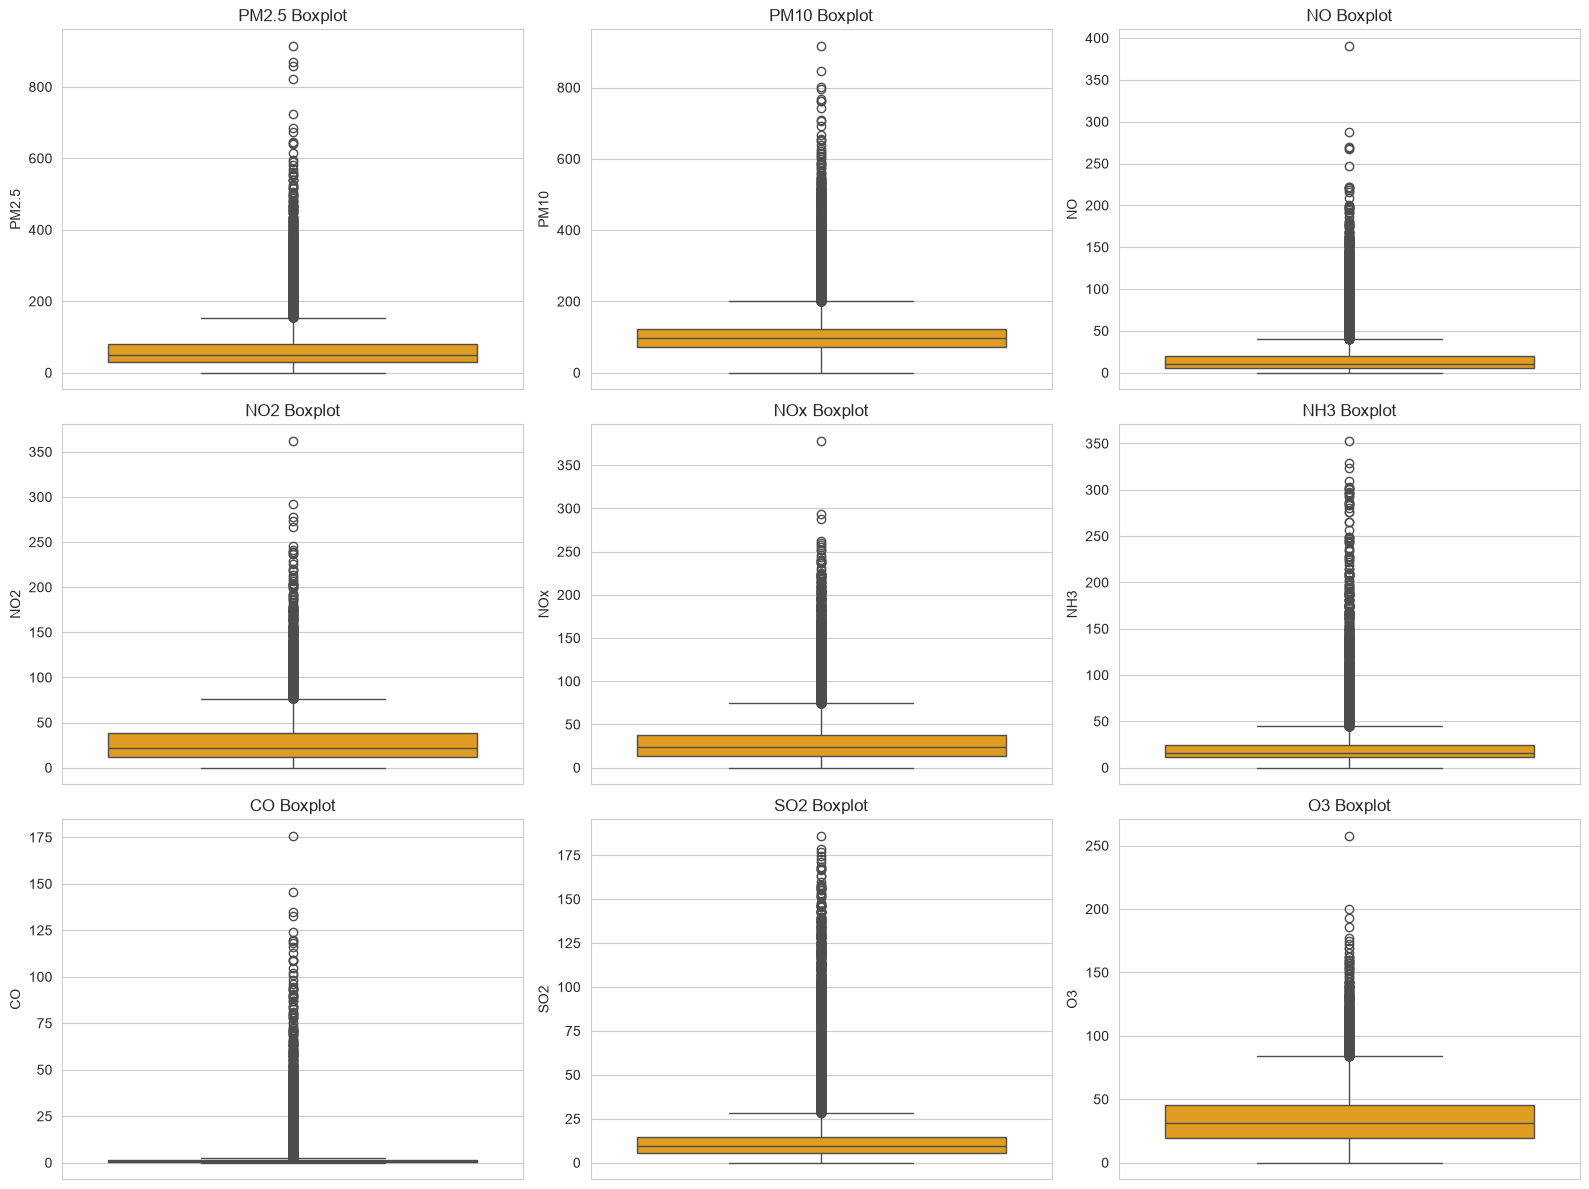

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(pollutants):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='orange')
    axes[i].set_title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

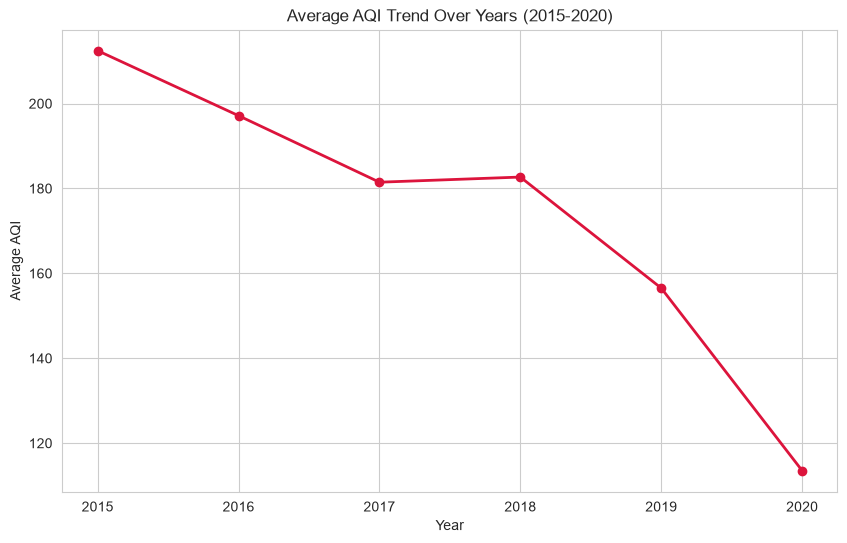

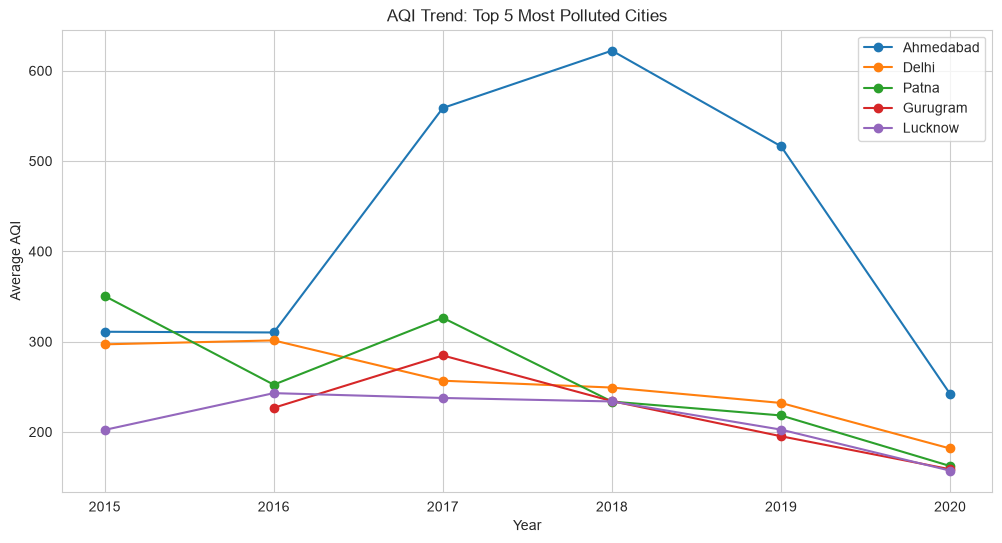

In [ ]:
try:
    df_trend = df_clean.dropna(subset=['Date']).copy()
    df_trend['Year'] = df_trend['Date'].dt.year

    # Overall yearly average AQI trend
    yearly_avg = df_trend.groupby('Year')['AQI'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    plt.plot(yearly_avg['Year'], yearly_avg['AQI'], marker='o', color='crimson', linewidth=2)
    plt.title('Average AQI Trend Over Years (2015-2020)')
    plt.xlabel('Year')
    plt.ylabel('Average AQI')
    plt.grid(True)
    plt.show()

    # Top 5 most polluted cities trend
    if 'City' in df_trend.columns:
        top_cities = df_trend.groupby('City')['AQI'].mean().sort_values(ascending=False).head(5).index
        plt.figure(figsize=(12, 6))
        for city in top_cities:
            city_data = df_trend[df_trend['City'] == city].groupby('Year')['AQI'].mean()
            plt.plot(city_data.index, city_data.values, marker='o', label=city)
        plt.title('AQI Trend: Top 5 Most Polluted Cities')
        plt.xlabel('Year')
        plt.ylabel('Average AQI')
        plt.legend()
        plt.grid(True)
        plt.show()
except Exception as e:
    print(f'Error plotting AQI trend: {e}')

In [ ]:
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
target = 'AQI'

X = df_clean[features]
y = df_clean[target]

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (24850, 9)
Target vector shape: (24850,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 19880
Testing samples:  4970


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15, n_jobs=-1)
}

predictions = {}
trained_models = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[name] = y_pred
        trained_models[name] = model
        print(f'{name} trained successfully')
    except Exception as e:
        print(f' Error training {name}: {e}')

Linear Regression trained successfully
Decision Tree Regressor trained successfully
Random Forest Regressor trained successfully


In [ ]:
results = {}

for name, y_pred in predictions.items():
    try:
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}
    except Exception as e:
        print(f' Error evaluating {name}: {e}')

results_df = pd.DataFrame(results).T.sort_values('R2 Score', ascending=False)
print('Model Comparison (sorted by R² Score):')
results_df

Model Comparison (sorted by R² Score):


,MAE,MSE,RMSE,R2 Score
Random Forest Regressor,21.098026,1647.357410,40.587651,0.910035
Decision Tree Regressor,25.037179,2681.946147,51.787510,0.853534
Linear Regression,31.183510,3533.200609,59.440732,0.807045


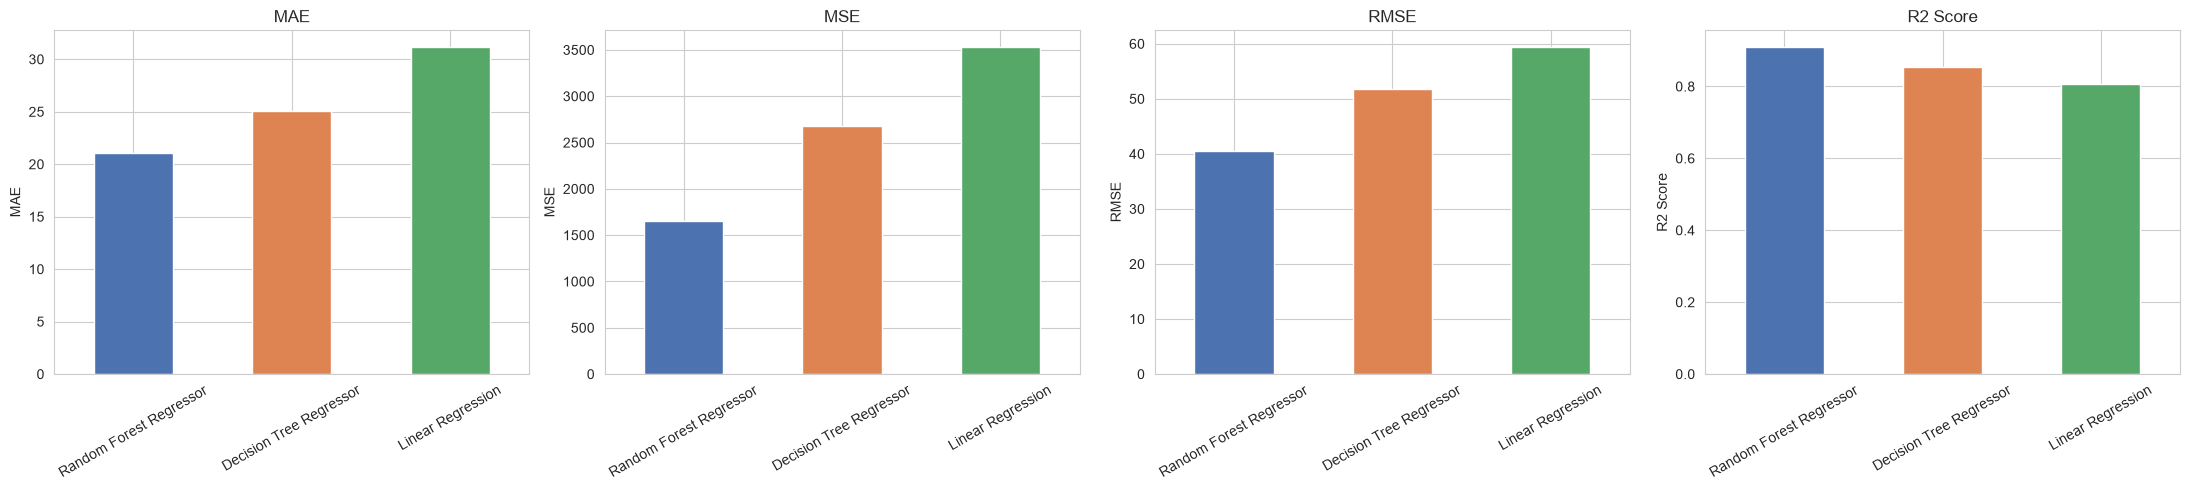

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar', ax=axes[i], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
best_model_name = results_df['R2 Score'].idxmax()
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f'Best Performing Model: {best_model_name}')
print()
print(results_df.loc[best_model_name])


from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


Best Performing Model: Random Forest Regressor

MAE           21.098026
MSE         1647.357410
RMSE          40.587651
R2 Score       0.910035
Name: Random Forest Regressor, dtype: float64


In [ ]:
def classify_aqi(aqi):
    """Classify a numeric AQI value into its standard category."""
    try:
        aqi = float(aqi)
    except (ValueError, TypeError):
        return 'Invalid'

    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

# Quick test
for test_val in [30, 80, 150, 250, 350, 450]:
    print(f'AQI {test_val} -> {classify_aqi(test_val)}')

AQI 30 -> Good
AQI 80 -> Satisfactory
AQI 150 -> Moderate
AQI 250 -> Poor
AQI 350 -> Very Poor
AQI 450 -> Severe


Classification Accuracy : 80.76%

Classification Report

              precision    recall  f1-score   support

        Good       0.84      0.65      0.73       282
    Moderate       0.82      0.85      0.83      1745
        Poor       0.68      0.65      0.67       555
Satisfactory       0.84      0.86      0.85      1655
      Severe       0.84      0.81      0.83       271
   Very Poor       0.76      0.73      0.74       462

    accuracy                           0.81      4970
   macro avg       0.80      0.76      0.78      4970
weighted avg       0.81      0.81      0.81      4970



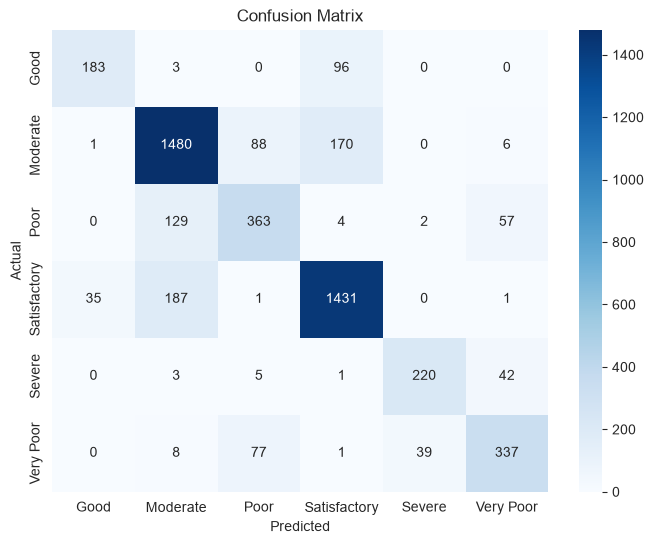

In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Convert AQI values into categories

df_clean['AQI_Category'] = df_clean['AQI'].apply(classify_aqi)

# Encode category names into numbers

label_encoder = LabelEncoder()

df_clean['AQI_Label'] = label_encoder.fit_transform(df_clean['AQI_Category'])

# Features

X_class = df_clean[features]

# Target

y_class = df_clean['AQI_Label']

# Train Test Split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

# Train Classifier

classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

classifier.fit(X_train_c, y_train_c)

# Prediction

y_pred_c = classifier.predict(X_test_c)

# Accuracy

accuracy = accuracy_score(y_test_c, y_pred_c)

print("Classification Accuracy : {:.2f}%".format(accuracy*100))

# Classification Report

print("\nClassification Report\n")

print(classification_report(
    y_test_c,
    y_pred_c,
    target_names=label_encoder.classes_
))

# Confusion Matrix

cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
def predict_custom_aqi(pm25, pm10, no, no2, nox, nh3, co, so2, o3, model=best_model):
    """
    Predicts AQI and category for a custom set of pollutant readings.
    Uses the best-performing trained model by default.
    """
    try:
        input_data = pd.DataFrame(
            [[pm25, pm10, no, no2, nox, nh3, co, so2, o3]],
            columns=features
        )
        predicted_aqi = model.predict(input_data)[0]
        category = classify_aqi(predicted_aqi)
        print(f'Predicted AQI : {predicted_aqi:.2f}')
        print(f'AQI Category  : {category}')
        return predicted_aqi, category
    except Exception as e:
        print(f' Error during custom prediction: {e}')
        return None, None

# Example: try your own pollutant values here
predict_custom_aqi(pm25=120, pm10=180, no=20, no2=40, nox=45, nh3=25, co=1.2, so2=15, o3=30)

Predicted AQI : 278.24
AQI Category  : Poor


(np.float64(278.24424189194974), 'Poor')

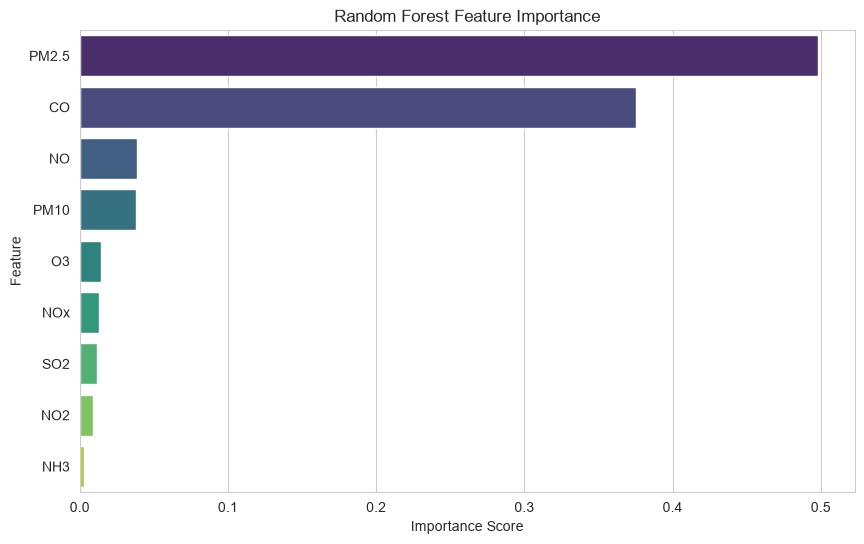

In [ ]:
try:
    rf_model = trained_models['Random Forest Regressor']
    importances = rf_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance Score')
    plt.show()

    feat_imp_df
except Exception as e:
    print(f' Error computing feature importance: {e}')

In [ ]:
try:
    output_df = X_test.copy().reset_index(drop=True)
    output_df['Actual_AQI'] = y_test.values
    output_df['Predicted_AQI'] = best_predictions
    output_df['AQI_Category'] = output_df['Predicted_AQI'].apply(classify_aqi)
    output_df['Model_Used'] = best_model_name

    output_df.to_csv('AQI_Predictions.csv', index=False)
    print(' File \'AQI_Predictions.csv\' exported successfully!')
    print(f'Rows exported: {output_df.shape[0]}')
    output_df.head(10)
except Exception as e:
    print(f' Error exporting CSV: {e}')

 File 'AQI_Predictions.csv' exported successfully!
Rows exported: 4970


In [ ]:
try:
    from google.colab import files
    files.download('AQI_Predictions.csv')
except Exception as e:
    print('Not running in Colab, or download failed. File is saved locally as AQI_Predictions.csv')
    print(e)

Not running in Colab, or download failed. File is saved locally as AQI_Predictions.csv
No module named 'google.colab'
